## Set up simulation

### Data

  **Cases**
- Start date: 2020
- End date: June 2023 

*Cases by catchment end date:

  **Wastewater**: 
- Start date: February 2021 (2/24/21)
- End date; November 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
print(smf)
from pathlib import Path
import covasim as cv

print(cv.__file__)
print(hasattr(cv, "Sim"))
print(cv.Sim)

<module 'statsmodels.formula.api' from '/storage/hcraddock/mamba/envs/covasim/lib/python3.10/site-packages/statsmodels/formula/api.py'>
Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM
/storage/hcraddock/GitHub/covasim4wastewater/covasim/__init__.py
True
<class 'covasim.sim.Sim'>


In [2]:
DATA_ROOT = Path.home() / "GitHub"
WW_REPO = DATA_ROOT / "SARS-CoV-2_WasteWater_San-Diego"
CASES_REPO = DATA_ROOT / "lone_pine" / "resources"

In [ ]:
##

### Data

In [54]:
cases = pd.read_csv(CASES_REPO/ "cases.csv")
zips = pd.read_csv(WW_REPO / "Zipcodes.csv")

In [ ]:
print(cases.shape)
cases.head()

### Data - Point Loma

In [ ]:
ww_pl = pd.read_csv(WW_REPO / "PointLoma_sewage_qPCR.csv")


In [8]:
ww_pl.head()

,Sample_Date,Mean viral gene copies/L
0,2/24/21,681730
1,2/28/21,943877
2,3/1/21,1034196
3,3/3/21,1918221
4,3/7/21,770022


In [44]:
cases_pl_total = cases[cases["catchment"] == "PointLoma"].copy()

In [45]:
cases_pl_total["updatedate"] = pd.to_datetime(cases_pl_total["updatedate"])   # strings -> dates
print(cases_pl_total.shape)
cases_pl_total.head()

(72339, 7)


,updatedate,ziptext,case_count,new_cases,days_past,population,catchment
0,2020-03-31,91902.0,0.0,0.0,1179,17653,PointLoma
1,2020-03-31,92113.0,0.0,0.0,1179,56066,PointLoma
2,2020-03-31,92111.0,0.0,0.0,1179,45096,PointLoma
3,2020-03-31,92110.0,0.0,0.0,1179,25341,PointLoma
4,2020-03-31,92109.0,0.0,0.0,1179,45787,PointLoma


In [16]:
cases_pl_total.tail()

,updatedate,ziptext,case_count,new_cases,days_past,population,catchment
127832,2023-06-13,92182.0,209.857143,0.0,10,606,PointLoma
127833,2023-06-14,92182.0,209.857143,0.0,9,606,PointLoma
127834,2023-06-15,92182.0,209.857143,0.0,8,606,PointLoma
127835,2023-06-16,92182.0,209.857143,0.0,7,606,PointLoma
127836,2023-06-17,92182.0,209.857143,0.0,6,606,PointLoma


### II. Aggregate Point Loma data across zip codes so one value per date
- Catchement population: 2,116,170

In [17]:
#Check Catchment population: one value per zip, not summed over all dates
print(cases_pl_total.groupby("ziptext")["population"].nunique().max(), "max distinct populations per zip (should be 1)")
CATCHMENT_POP = cases_pl_total.groupby("ziptext")["population"].max().sum()
print("Catchment population:", CATCHMENT_POP)

1 max distinct populations per zip (should be 1)
Catchment population: 2116170


In [46]:
# One row per date, summed across Point Loma zips
df_cases_pl = (cases_pl_total.groupby("updatedate", as_index=False)
                 .agg(case_count=("case_count", "sum"),
                      new_cases=("new_cases", "sum"),
                      n_zips=("ziptext", "nunique")))

In [47]:
### Add daily rate per 100,000
df_cases_pl["new_cases_per_100k"] = (df_cases_pl["new_cases"] / CATCHMENT_POP)*100_000

In [48]:
print(df_cases_pl.shape)
df_cases_pl.head()

(1174, 5)


,updatedate,case_count,new_cases,n_zips,new_cases_per_100k
0,2020-03-31,0.0,0.0,55,0.000000
1,2020-04-01,87.0,87.0,55,4.111201
2,2020-04-02,214.0,127.0,56,6.001408
3,2020-04-03,289.0,75.0,57,3.544139
4,2020-04-04,343.0,54.0,57,2.551780


In [49]:
print(df_cases_pl["updatedate"].dtype)   # expect datetime64[ns])
df_cases_pl["updatedate"].nunique()

datetime64[ns]


1174

## Omicron wave

In [25]:
# Omicron dates
FIT_START = pd.Timestamp("2021-11-15")
FIT_END   = pd.Timestamp("2022-03-01")

In [34]:
# Step 1: pick the column, with the date as the index
cases_pl = df_cases_pl.set_index("updatedate")["new_cases_per_100k"]

In [41]:
df_cases_pl.tail()

,updatedate,case_count,new_cases,n_zips,new_cases_per_100k
1169,2023-06-13,654270.142857,0.714286,62,0.033754
1170,2023-06-14,654270.857143,0.714286,62,0.033754
1171,2023-06-15,654271.571429,0.714286,62,0.033754
1172,2023-06-16,654272.285714,0.714286,62,0.033754
1173,2023-06-17,654273.000000,0.714286,62,0.033754


In [50]:
w = df_cases_pl.set_index("updatedate").loc[FIT_START:FIT_END]
print(len(w), "days in window")
print("zero days in window:", (w["new_cases"] == 0).sum())
print("non-integer share (raw counts):", (w["new_cases"].round() != w["new_cases"]).mean())
print(w.loc[w["new_cases"] == 0].index.date)

107 days in window
zero days in window: 0
non-integer share (raw counts): 1.0
[]


In [51]:
# Step 2: Cases omicron
cases_omicicron_pl = df_cases_pl.set_index("updatedate")["new_cases"].loc[FIT_START:FIT_END]

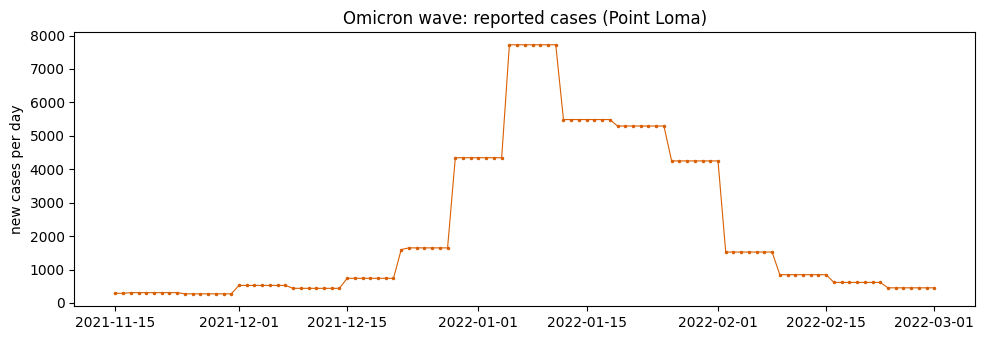

In [52]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(cases_omicicron_pl.index, cases_omicicron_pl, ".-", ms=3, lw=0.8, color="#D95F02")
ax.set_ylabel("new cases per day")
ax.set_title("Omicron wave: reported cases (Point Loma)")
plt.tight_layout()
plt.show()

In [53]:
cases_omicicron_pl

updatedate
2021-11-15    289.285714
2021-11-16    289.285714
2021-11-17    308.857143
2021-11-18    308.857143
2021-11-19    308.857143
                 ...    
2022-02-25    453.000000
2022-02-26    453.000000
2022-02-27    453.000000
2022-02-28    453.000000
2022-03-01    453.000000
Name: new_cases, Length: 107, dtype: float64

In [ ]:



# Wastewater: only the days that have a measurement
ww_obs = (ww.set_index("date")["ww_copies_per_L"]
            .sort_index()
            .loc[FIT_START:FIT_END])

print(len(cases_obs), "case days;", len(ww_obs), "wastewater days")
print(cases_obs.describe())

## Simulation

In [ ]:

POP_SIZE = 50_000
POP_SCALE = CATCHMENT_POP / POP_SIZE        # sim agents represent the real catchment population
LEAD_IN = 21                                 # days of warm-up before the fit window

sim = cv.Sim(
    pop_size=POP_SIZE,
    pop_scale=POP_SCALE,
    pop_type='hybrid',
    
    location='usa',                          # see note below
    pop_infected=500,
    n_imports=0,
    start_day=FIT_START - pd.Timedelta(days=LEAD_IN),
    end_day=FIT_END,
    interventions=[testing],
    verbose=0,
)
sim.run()

df = extract_wastewater_regression_data(sim)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

# Cases in the same units as the data
df["cases_per_100k"] = df["cases"] / CATCHMENT_POP * 100_000
print(df.head())